In [2]:
from sklearn.model_selection import train_test_split
import numpy as np
import os


In [3]:
#--- Create the dataset ---# 

# 0:Met[Zsun],1:Age[Gyr],2:Rp[Rsun],3:Vinf[km/s],4:Mass1_i[MSUN],5:Mass2_i[Msun],6:R1[Rsun],7:R2[Rsun],8:Label,9:Mass1_f[MSUN],10:Mass2_f[MSUN],11:Sigma
# data_dir = '/projects/b1091/SPH_ML_grid/machine_learning/data_n10k_splot22f.csv'
data_dir = '../../data_n10k_splot22f.csv'

data_loaded  = np.loadtxt(data_dir, delimiter=',', dtype=float, skiprows = 1)

# Selecting only specific columns:
data = data_loaded[:, [1, 2, 3, 4, 5, 8]]

y_data = data[:,-1].astype(np.int64).copy()
x_data = data[:, :-1].copy()
#Feature transform: log the x-data
x_data[:, 0] = np.log10(x_data[:, 0]) # log ages
x_data[:, 1] = np.log10(x_data[:, 1] + 1) # log rp
x_data[:, 2] = np.log10(x_data[:, 2]) # log vinfs
x_data[:, 3] = np.log(x_data[:, 3])   # ln M1,i
x_data[:, 4] = np.log(x_data[:, 4])   # ln M2,i
y_data[y_data < 0] = 3 #replace locally the meaning of label -1

print(np.shape(x_data), np.shape(y_data))

# Split into Training + Temporary (Validation + Test)
X_train, X_temp, y_train, y_temp = train_test_split(x_data, y_data, test_size=0.30, stratify = y_data, random_state=42)

# Split the temporary into validation and testing sets 
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify = y_temp, random_state=42)

print(np.shape(X_train), np.shape(X_val), np.shape(X_test))

# Save these splits
# np.savez('data_splits_splot22f.npz', X_train=X_train, y_train=y_train, X_val=X_val, y_val=y_val, X_test=X_test, y_test=y_test)

(21473, 5) (21473,)
(15031, 5) (3221, 5) (3221, 5)


In [6]:
print(np.isnan(X_train).sum(axis=0))  # per feature
print(np.isnan(X_val).sum(axis=0))  # per feature
print(np.isnan(X_test).sum(axis=0))  # per feature

print(np.isinf(X_train).sum(axis=0))
print(np.isinf(X_val).sum(axis=0))
print(np.isinf(X_test).sum(axis=0))

[0 0 0 0 0]
[0 0 0 0 0]
[0 0 0 0 0]
[0 0 0 0 0]
[0 0 0 0 0]
[0 0 0 0 0]


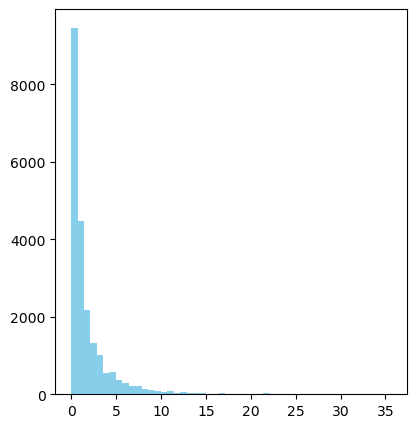

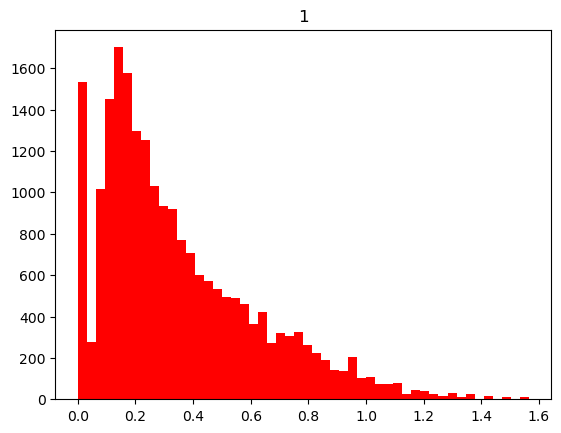

In [34]:
import matplotlib.pyplot as plt
for i in range(1,2):
    # Plot comparison
    plt.figure(figsize=(10,5))

    
    plt.subplot(1,2,1)
    plt.hist(data[:, i], bins=50, color="skyblue")
    plt.show()

    plt.hist(x_data[:, i], bins=50, color="red")
    plt.title(str(i))



    plt.show()
